# Crop Emulator based on Liu et al. 2023

## Variables for for irrigated emulators

### 1) XGBoost Models can be found here: https://zenodo.org/record/7796686
- for each Crop Model, Scenario (A0 or A1) crop type (winter wheat, spring wheat, maize, rice) and irrigation type (rainfed or irrigated)
- try with crop emulator: XGBpred38_GEPIC_A0_swh_rf
    - rainfed: water supply is only precipitation
        - reason: compound events are dry and hot, therfore we want the effect of drieness too
    - spring wheat: good results and important for europe
    - A0: maximum effect of climate change, no adaption
    - crop model: GEPIC, as defined in baseline study

    -> we need to find predictors for exactly this configuration

    - **keep in mind for AI RARES**
        - climate data: will be later given by AI RARES CAMulator, so its not that important for now which we use as we chnage them later anyways
        - crop specific data: may be not given by AI RARES, so we need to stick to Liu et al., 2023 hwhich data the used
        - open question: WP1.2: Calibration of GeoEPIC for the European context (PhD2): will crop specific data be used here and maybe is available?
        - list of crop specific predicotrs (everthying not from climate model output):
            - Growing season dates -> most important
                - planting date
                - growing season length
            - soil type
            - nitrogen fertilizer application
            - maybe: CO2 concentration


### 2) Documentation of the predictors can be found here: https://zenodo.org/records/7796686
- word document:Emulator function description.docx

- **Predictors for XGBpred38_GEPIC_A0_swh_rf**
| Order | Predictor | Unit |
|---:|---|---|
| 1–10 | Monthly avg daily max temp | °C |
| 11–20 | Monthly avg daily min temp | °C |
| 21–30 | Monthly avg daily solar radiation | W/m² |
| 31–40 | Monthly total precipitation | mm |
| 41 | Growing degree day | Degree days |
| 42 | Extreme degree day during growing | Degree days |
| 43 | Growing-season avg daily max temp | °C |
| 44 | Growing-season avg daily min temp | °C |
| 45 | Growing-season total precipitation | mm |
| 46 | Growing-season avg daily solar radiation | W/m² |
| 47 | Growing-season SD daily max temp | °C |
| 48 | Growing-season SD daily min temp | °C |
| 49 | Growing-season SD daily precipitation | mm |
| 50 | Growing-season SD daily solar radiation | W/m² |
| 51 | Consecutive drought days | days |
| 52 | Soil type | Class number |
| 53 | CO₂ concentration | ppm |
| 54 | Nitrogen fertilizer application | kg/ha |
| 55 | Spatial difference term | Growing-season length days |

- Example for Monthly avg daily max temp 1-10 means: months since planting date
- for  each grid cell A:
    - spring wheat planting date = 15. März
        - MON_1  = 15. März – 14. April
        - MON_2  = 15. April – 14. Mai
        - MON_3  = 15. Mai – 14. Juni
        - ...
        - MON_10 = 15. Dezember – 14. Januar

### 3) Data Sources for the Predictors
- GGCMI Phase 2 datasets can be found here: https://zenodo.org/records/3773827
- proivides 3 data sets, all for global coverage with saptial resolution of 0.5°:
    - Growing Season length, Sason start, season end
    - boolean mask for croplands
    - boolean mask for swh, wwh

- soil database can be found here: https://www.fao.org/soils-portal/soil-survey/soil-maps-and-databases/harmonized-world-soil-database-v12/en/
    - more infromation on the soil database can be found here: https://www.researchgate.net/publication/228068266_The_Harmonized_World_Soil_Database
    - its not clearly stated in Liu et al, which soil type data they used
    - I guess they used the variable: T_USDA_TEX_CLASS
        - it contains 13 soil types from sand to heavy clay, which is stated in the paper







## Load and inspect XGBoost model

In [1]:
# ============================================================
# 0. Imports
# ============================================================

import os
import json
import joblib
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pprint
import rasterio

In [3]:
# ============================================================
# 1. Define paths
# ============================================================

data_dir = "/Users/patricemahlau/Documents/Uni_Leipzig_Arbeit/data/"

old_model_file = "XGBpred38_GEPIC_A0_swh_rf"
json_model_file = "XGBpred38_GEPIC_A0_swh_rf.json"

old_model_path = os.path.join(data_dir, old_model_file)
json_model_path = os.path.join(data_dir, json_model_file)

print("XGBoost version:", xgb.__version__)
print("Old model path:", old_model_path)

XGBoost version: 1.7.6
Old model path: /Users/patricemahlau/Documents/Uni_Leipzig_Arbeit/data/XGBpred38_GEPIC_A0_swh_rf


In [4]:
# ============================================================
# 2. Load old serialized model
# ============================================================

model = joblib.load(old_model_path)

print("Loaded object type:")
print(type(model))

[11:49:01] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1700181009589/work/src/learner.cc:1203: 
  If you are loading a serialized model (like pickle in Python, RDS in R) generated by
  older XGBoost, please export the model by calling `Booster.save_model` from that version
  first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/latest/tutorials/saving_model.html

  for more details about differences between saving model and serializing.

[11:49:01] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1700181009589/work/src/learner.cc:888: Found JSON model saved before XGBoost 1.6, please save the model using current version again. The support for old JSON model will be discontinued in XGBoost 2.3.
[11:49:02] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1700181009589/work/src/learner.cc:553: 
  If you are loading a serialized model (like pickle in Python, RDS in R) generated by
  older XGBoost, please export the model by

In [5]:
# ============================================================
# 3. Extract Booster and save as stable JSON
# ============================================================

booster_old = model.get_booster()

booster_old.save_model(json_model_path)

print("Saved converted JSON model to:")
print(json_model_path)

Saved converted JSON model to:
/Users/patricemahlau/Documents/Uni_Leipzig_Arbeit/data/XGBpred38_GEPIC_A0_swh_rf.json


In [6]:
# ============================================================
# 4. Reload JSON model as pure XGBoost Booster
# ============================================================

booster = xgb.Booster()
booster.load_model(json_model_path)

print("Reloaded JSON Booster:")
print(type(booster))


Reloaded JSON Booster:
<class 'xgboost.core.Booster'>


In [7]:
# ============================================================
# 5. Basic model inspection
# ============================================================

print("Number of features:")
print(booster.num_features())

print("Number of boosted rounds / trees:")
print(booster.num_boosted_rounds())

print("Feature names:")
print(booster.feature_names)


Number of features:
55
Number of boosted rounds / trees:
4000
Feature names:
None


In [8]:
# ============================================================
# 6. Inspect full XGBoost configuration
# ============================================================

config = json.loads(booster.save_config())

print(json.dumps(config, indent=2))


{
  "learner": {
    "generic_param": {
      "fail_on_invalid_gpu_id": "0",
      "gpu_id": "-1",
      "n_jobs": "0",
      "nthread": "0",
      "random_state": "0",
      "seed": "0",
      "seed_per_iteration": "0",
      "validate_parameters": "1"
    },
    "gradient_booster": {
      "gbtree_model_param": {
        "num_parallel_tree": "1",
        "num_trees": "4000",
        "size_leaf_vector": "0"
      },
      "gbtree_train_param": {
        "predictor": "auto",
        "process_type": "default",
        "tree_method": "auto",
        "updater": "grow_colmaker,prune",
        "updater_seq": "grow_colmaker,prune"
      },
      "name": "gbtree",
      "specified_updater": false,
      "updater": {
        "grow_colmaker": {
          "colmaker_train_param": {
            "default_direction": "learn",
            "opt_dense_col": "1"
          },
          "train_param": {
            "alpha": "0",
            "cache_opt": "1",
            "colsample_bylevel": "1",
         

In [9]:

# ============================================================
# 7. Feature importance
# ============================================================

importance_gain = booster.get_score(importance_type="gain")
importance_weight = booster.get_score(importance_type="weight")
importance_cover = booster.get_score(importance_type="cover")

importance_df = pd.DataFrame({
    "feature": list(importance_gain.keys()),
    "gain": list(importance_gain.values())
}).sort_values("gain", ascending=False)

print("Feature importance by gain:")
print(importance_df.head(30))

print(importance_weight)

Feature importance by gain:
   feature        gain
42     f42  604.325928
44     f44  403.836700
54     f54  208.180191
34     f34   93.960861
41     f41   86.533737
51     f51   71.819389
53     f53   65.871880
36     f36   63.831661
30     f30   51.530949
47     f47   48.704239
31     f31   46.270462
40     f40   40.713516
35     f35   38.942993
38     f38   38.495243
21     f21   38.112610
26     f26   37.155300
46     f46   33.656746
27     f27   33.118782
45     f45   30.185583
23     f23   29.474819
25     f25   27.618505
32     f32   27.609713
39     f39   27.265699
22     f22   24.610764
52     f52   24.458424
37     f37   24.309553
33     f33   23.028030
48     f48   22.925756
24     f24   22.721210
29     f29   22.523146
{'f0': 180376.0, 'f1': 50607.0, 'f2': 99806.0, 'f3': 187638.0, 'f4': 42974.0, 'f5': 30885.0, 'f6': 75862.0, 'f7': 101798.0, 'f8': 34691.0, 'f9': 26759.0, 'f10': 70723.0, 'f11': 90106.0, 'f12': 31661.0, 'f13': 25121.0, 'f14': 69162.0, 'f15': 85082.0, 'f16': 30

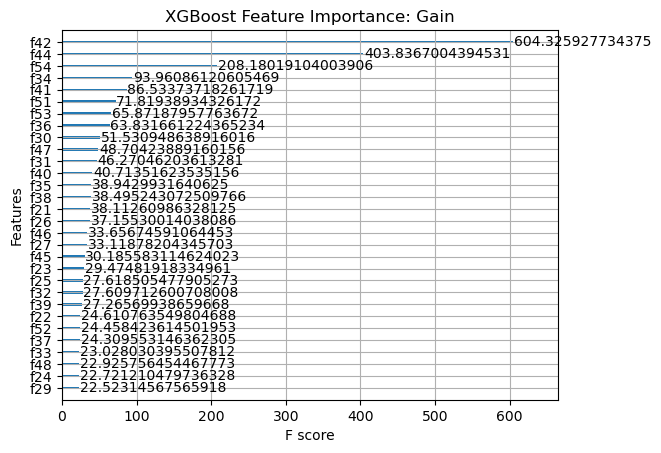

In [10]:
# ============================================================
# 8. Plot feature importance
# ============================================================

xgb.plot_importance(
    booster,
    importance_type="gain",
    max_num_features=30
)

plt.title("XGBoost Feature Importance: Gain")
plt.show()


In [11]:
# ============================================================
# 9. Inspect tree structure as table
# ============================================================

trees_df = booster.trees_to_dataframe()

print("Tree dataframe shape:")
print(trees_df.shape)

print("First rows of tree dataframe:")
print(trees_df.head())


Tree dataframe shape:
(6930776, 11)
First rows of tree dataframe:
   Tree  Node   ID Feature       Split   Yes    No Missing         Gain  \
0     0     0  0-0     f44  120.849998   0-1   0-2     0-1  4614682.000   
1     0     1  0-1     f34    2.830645   0-3   0-4     0-4   610095.688   
2     0     2  0-2     f53   60.000000   0-5   0-6     0-5  3261410.000   
3     0     3  0-3     f39   10.797501   0-7   0-8     0-7    85199.000   
4     0     4  0-4     f44   77.130005  0-11  0-12    0-11   333905.812   

        Cover  Category  
0  21852058.0       NaN  
1   5803887.0       NaN  
2  16048171.0       NaN  
3   1133849.0       NaN  
4   4670038.0       NaN  


In [12]:


# ============================================================
# 10. Inspect one tree as text
# ============================================================

tree_dump = booster.get_dump()

print("Number of trees:")
print(len(tree_dump))

print("First tree:")
print(tree_dump[0])

Number of trees:
4000
First tree:
0:[f44<120.849998] yes=1,no=2,missing=1
	1:[f34<2.83064508] yes=3,no=4,missing=4
		3:[f39<10.7975006] yes=7,no=8,missing=7
			7:[f31<19.3325005] yes=15,no=16,missing=16
				15:[f42<23.2597599] yes=31,no=32,missing=31
					31:[f27<19.8450012] yes=63,no=64,missing=64
						63:[f48<1.98238516] yes=127,no=128,missing=127
							127:[f35<16.2224998] yes=255,no=256,missing=255
								255:[f3<22.5550003] yes=511,no=512,missing=511
									511:[f27<11.6750002] yes=1023,no=1024,missing=1023
										1023:leaf=-0.00563795678
										1024:leaf=0.0203634594
									512:[f11<67.5400009] yes=2043,no=2044,missing=2043
										2043:leaf=0.0406616405
										2044:leaf=0.125809208
								256:[f37<-16.5943546] yes=1019,no=1020,missing=1019
									1019:[f23<26.8400002] yes=1045,no=1046,missing=1046
										1045:leaf=0.0217799395
										1046:leaf=0.0775871128
									1020:[f34<1.14677417] yes=1041,no=1042,missing=1041
										1041:leaf=0.110797465
				

## GGCMI Phase 2 datasets

<xarray.Dataset>
Dimensions:                (lon: 720, lat: 360)
Coordinates:
  * lon                    (lon) float64 -179.8 -179.2 -178.8 ... 179.2 179.8
  * lat                    (lat) float64 -89.75 -89.25 -88.75 ... 89.25 89.75
Data variables:
    harvest day            (lat, lon) float32 ...
    planting day           (lat, lon) float32 ...
    growing season length  (lat, lon) float32 ...
    data source used       (lat, lon) float32 ...
Attributes:
    title:     prescribed planting and harvest dates for Ag-GRID GGCMI harmon...
    comment1:  areas where fastest-maturing variety should be used are flagge...
    comment2:  areas where no suitable sowing date could be derived are flagg...
    comment3:  dates created from LPJmL rule based dates (Waha et al. 2012), ...
<xarray.Dataset>
Dimensions:        (lon: 720, lat: 360)
Coordinates:
  * lon            (lon) float64 -179.8 -179.2 -178.8 ... 178.8 179.2 179.8
  * lat            (lat) float64 -89.75 -89.25 -88.75 ... 88.75 89.2

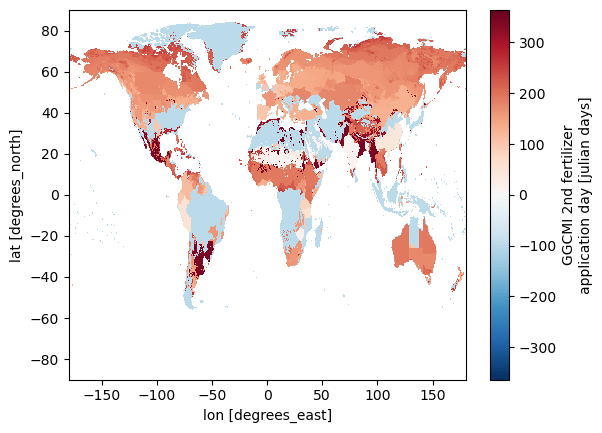

In [25]:
# growing season data

data_dir_agmip = r"../data/ggcmi_phase_2_data/AGMIP_GROWING_SEASON.HARM.version2.0/"
file_swh = "swh_rf_growing_season_dates_v2.nc4"

data_path = os.path.join(data_dir_agmip, file_swh)

ds = xr.open_dataset(data_path, engine = "netcdf4")
print(ds)
grow_season = ds["growing season length"]
# grow_season.plot()

fertilizer = xr.open_dataset(data_dir_agmip + "swh_rf_2nd_fertilizer_days_disseminate_v2.nc4", engine = "netcdf4")
print(fertilizer)

fertilizer["2nd fert appl"].plot()

<xarray.Dataset>
Dimensions:                (lon: 720, lat: 360)
Coordinates:
  * lon                    (lon) float64 -179.8 -179.2 -178.8 ... 179.2 179.8
  * lat                    (lat) float64 -89.75 -89.25 -88.75 ... 89.25 89.75
Data variables:
    minimum cropland mask  (lat, lon) float32 ...
Attributes:
    title:      minimum cropland to be simulated in GGCMI phase 2 simulations
    author:     Christoph Mueller, PIK cmueller@pik-potsdam.de
    comment 1:  use this mask to mask out unsuitable areas from simulations f...
    comment 2:  unsuitability is based on GAEZ; Grid-cells are marked as unsi...
    comment 3:  unsuitability is neglected, if pixel is used for cropland (an...


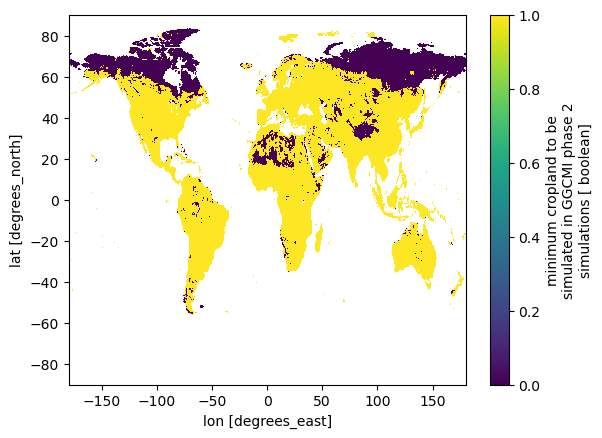

In [28]:
# cropmask

data_dir_ggcmi = r"../data/ggcmi_phase_2_data"
file_swh = "boolean_cropmask_ggcmi_phase2.nc4"

data_path = os.path.join(data_dir_ggcmi, file_swh)

cropmask = xr.open_dataset(data_path, engine = "netcdf4")
print(cropmask) #cropmask
cropmask["minimum cropland mask"].plot()

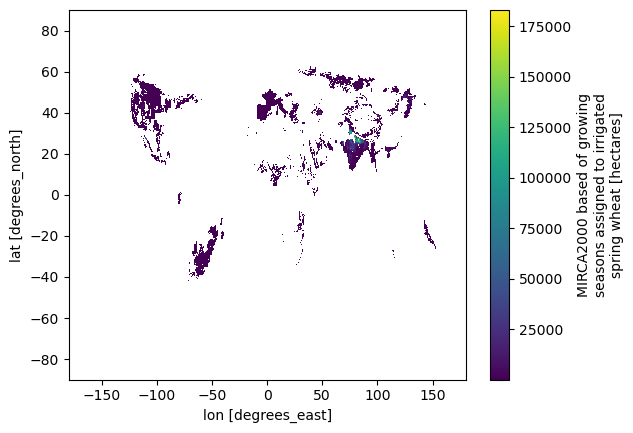

In [16]:
# winter and spring wheat areas 

spring_mask_file = "winter_and_spring_wheat_areas_v1_180627.nc4"

data_path = os.path.join(data_dir_ggcmi, spring_mask_file)

sw_mask = xr.open_dataset(data_path, engine = "netcdf4")
sw_mask["swh_ir_area"].plot()

## Soil Type Cover Data

In [8]:
import rasterio
import pandas as pd
import subprocess
import io

# 1. Pfad setzen
data_path = "/Users/patricemahlau/Documents/Uni_Leipzig_Arbeit/data/soil_data/"

# 2. Raster laden (.bil benötigt .hdr im selben Ordner)
with rasterio.open(data_path + "hwsd.bil") as src:
    soil_raster = src.read(1)  # Das Array mit den MU_GLOBAL IDs
    profile = src.profile      # Metadaten für späteres Speichern/Verschneiden

# 3. Datenbank (.mdb) auslesen
# Da pyodbc auf Mac oft scheitert, nutzen wir mdbtools direkt:
def read_mdb_table(db_path, table_name):
    cmd = ["mdb-export", db_path, table_name]
    output = subprocess.run(cmd, capture_output=True, text=True)
    return pd.read_csv(io.StringIO(output.stdout))

# Tabelle 'HWSD_DATA' laden (enthält die Zuordnung ID -> Bodentyp)
df_attr = read_mdb_table(data_path + "HWSD.mdb", "HWSD_DATA")

# 4. Minimales Mapping Beispiel
# Erstellt ein Dictionary: MU_GLOBAL -> Soil Type (z.B. SU_SYM90)
id_to_type = dict(zip(df_attr['MU_GLOBAL'], df_attr['SU_SYM90']))

print(f"Raster Shape: {soil_raster.shape}")
print(f"Beispiel Mapping (ID 7001): {id_to_type.get(7001)}")

Raster Shape: (21600, 43200)
Beispiel Mapping (ID 7001): UR


/var/folders/tq/7tmqzvd562d2hp2ywmvltd1r0000gn/T/ipykernel_54938/1578217570.py:19: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(io.StringIO(output.stdout))


In [10]:
df_attr

,ID,MU_GLOBAL,MU_SOURCE1,MU_SOURCE2,ISSOIL,SHARE,SEQ,SU_SYM74,SU_CODE74,SU_SYM85,...,S_CEC_CLAY,S_CEC_SOIL,S_BS,S_TEB,S_CACO3,S_CASO4,S_ESP,S_ECE,T_BULK_DENSITY,S_BULK_DENSITY
0,2,7002,2,2.0,0,100.0,1,NaN,NaN,HD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,7003,3,3.0,0,100.0,1,NaN,NaN,WR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4,7004,4,4.0,0,100.0,1,NaN,NaN,Od,...,71.0,78.0,40.0,27.4,0.0,0.0,1.0,0.1,0.10,0.10
3,5,7005,5,5.0,0,100.0,1,NaN,NaN,GG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6,7006,70001,70001.0,1,70.0,1,NaN,NaN,Tv,...,146.0,10.0,23.0,5.3,0.0,0.0,1.0,0.1,0.99,0.97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48143,48145,32049,TN249,NaN,1,20.0,4,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.30,NaN
48144,48146,32050,TN250,NaN,1,50.0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.30,NaN
48145,48147,32050,TN250,NaN,1,30.0,2,NaN,NaN,NaN,...,37.0,3.0,100.0,3.1,5.7,0.1,4.0,1.0,1.50,1.49
48146,48148,32050,TN250,NaN,1,20.0,3,NaN,NaN,NaN,...,27.0,4.0,90.0,3.6,3.0,0.2,2.0,0.1,1.16,1.14


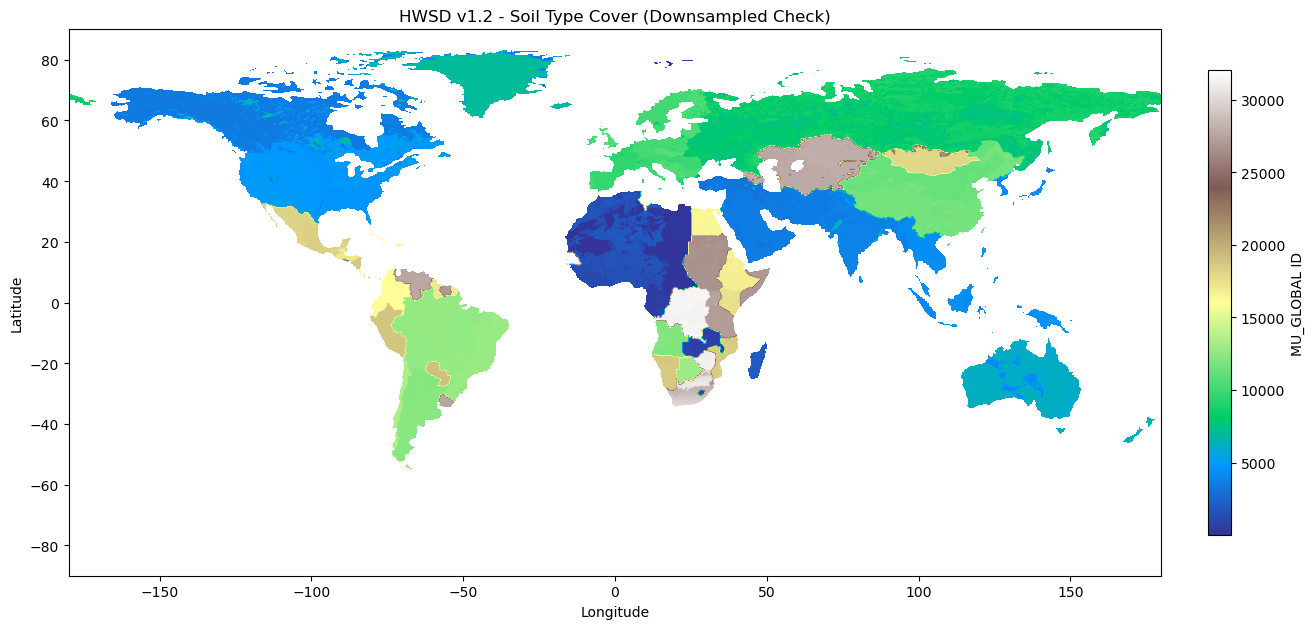

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Daten für den Plot vorbereiten (Downsampling auf 10% für Speed)
# Wir nutzen [::10, ::10] um nur jeden 10. Pixel zu nehmen
plot_data = soil_raster[::10, ::10].astype(float)

# 2. No-Data Werte maskieren (in HWSD v1.2 oft 0)
plot_data[plot_data == 0] = np.nan

# 3. Plot erstellen
plt.figure(figsize=(15, 8))
img = plt.imshow(plot_data, cmap='terrain', extent=[-180, 180, -90, 90])
plt.colorbar(img, label='MU_GLOBAL ID', fraction=0.02, pad=0.04)

plt.title("HWSD v1.2 - Soil Type Cover (Downsampled Check)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [12]:
import numpy as np

# 1. Erstelle ein Mapping-Array (Index = MU_GLOBAL, Wert = Texture Class)
# Wir finden die höchste ID, um die Größe des Arrays festzulegen
max_id = int(df_attr['MU_GLOBAL'].max())
# Initialisiere mit 0 (für Wasser/NoData)
mapping_array = np.zeros(max_id + 1, dtype=np.float32) 

# Fülle das Array mit den Werten aus der Datenbank
for _, row in df_attr.iterrows():
    mapping_array[int(row['MU_GLOBAL'])] = row['T_USDA_TEX_CLASS']

# 2. Das eigentliche Mapping (Blitzschnell)
# Wir behandeln NaN im soil_raster vorab:
soil_raster_clean = np.nan_to_num(soil_raster, nan=0).astype(int)

# Hier passiert die Magie: Jeder Wert im Raster wird als Index für das Mapping-Array genutzt
texture_raster = mapping_array[soil_raster_clean]

# 3. Jetzt kannst du die NaNs wieder setzen, wo vorher Wasser (0) war
texture_raster[texture_raster == 0] = np.nan

print("Texture Raster erfolgreich erstellt!")


Texture Raster erfolgreich erstellt!


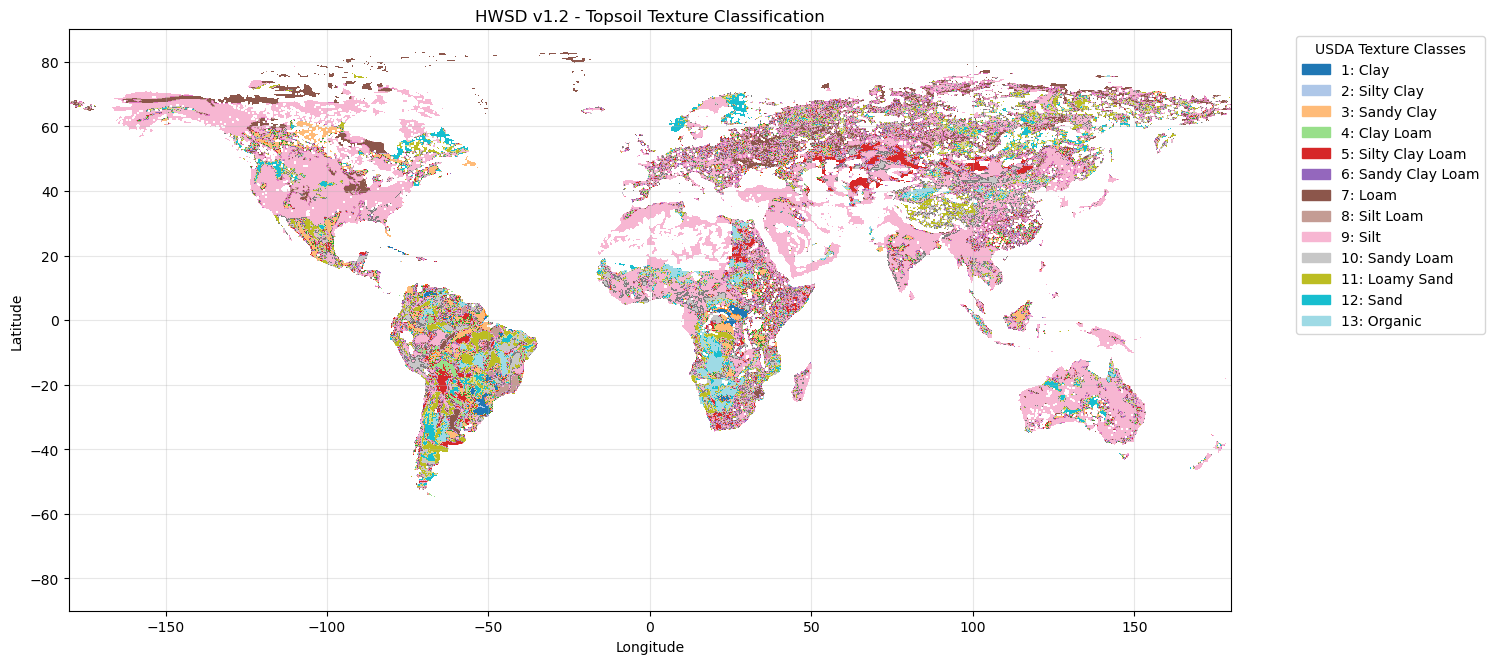

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# 1. Namen der USDA Klassen laut Dokumentation
tex_names = {
    1: "Clay", 2: "Silty Clay", 3: "Sandy Clay", 4: "Clay Loam", 
    5: "Silty Clay Loam", 6: "Sandy Clay Loam", 7: "Loam", 
    8: "Silt Loam", 9: "Silt", 10: "Sandy Loam", 
    11: "Loamy Sand", 12: "Sand", 13: "Organic"
}

# 2. Plot Setup
plt.figure(figsize=(15, 8))

# Wir nutzen einen Ausschnitt (Downsampling), um den RAM zu schonen
# cmap 'tab20' bietet gute Unterscheidung für die 13 Klassen
im = plt.imshow(texture_raster[::20, ::20], cmap='tab20', 
                extent=[-180, 180, -90, 90])

# 3. Legende manuell erstellen
# Wir holen uns die Farben aus der Map, die tatsächlich im Raster vorkommen
colors = [im.cmap(im.norm(i)) for i in tex_names.keys()]
patches = [mpatches.Patch(color=colors[i-1], label=f"{i}: {tex_names[i]}") 
           for i in tex_names.keys()]

plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', title="USDA Texture Classes")

plt.title("HWSD v1.2 - Topsoil Texture Classification")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(alpha=0.3)

plt.show()